# Análisis de DIN

## 1.- Importación y funciones

In [2]:
import os
import numpy as np
import pandas as pd
#import ydata_profiling
#from ydata_profiling import ProfileReport
import dtale
#from google.colab import drive
from sklearn.feature_selection import VarianceThreshold

from matplotlib import pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
#import plotly.express as px

import meteostat as ms
from datetime import date


In [3]:
pd.set_option('display.max_columns', None)

In [4]:
# 1. Montar Google Drive
#drive.mount('/content/drive')

In [7]:

# Placeholder para la siguiente parte del código
# Puedes modificar esta celda una vez que me proporciones más detalles.
# Por ejemplo:
#folder_path = '/content/drive/MyDrive/Master Data Science & Business Analytics/Logística/ProyectoLogística/'

folder_path = '../'

In [8]:
path_data = 'data/aduanas/'
df_ac = pd.read_csv(folder_path + path_data+'aduanas_df.csv', sep= ';', encoding='utf-8')
df_ac.head()

C:\Users\oaceb\AppData\Local\Temp\ipykernel_16844\958403452.py:2: DtypeWarning:

Columns (0: MON_OTR2, 1: CTA_OTR7, 2: MON_OTR7, 3: ADVAL-ALA, 4: SIGVAL4, 5: VAL4) have mixed types. Specify dtype option on import or set low_memory=False.



,NUMENCRIPTADO,TIPO_DOCTO,ADU,FORM,FECVENCI,CODCOMUN,NUM_UNICO_IMPORTADOR,CODPAISCON,DESDIRALM,CODCOMRS,ADUCTROL,NUMPLAZO,INDPARCIAL,NUMHOJINS,TOTINSUM,CODALMA,NUM_RS,FEC_RS,ADUA_RS,NUMHOJANE,NUM_SEC,PA_ORIG,PA_ADQ,VIA_TRAN,TRANSB,PTO_EMB,PTO_DESEM,TPO_CARGA,ALMACEN,FEC_ALMAC,FECRETIRO,NU_REGR,ANO_REG,CODVISBUEN,NUMREGLA,NUMANORES,CODULTVB,PAGO_GRAV,FECTRA,FECACEP,GNOM_CIA_T,CODPAISCIA,NUMRUTCIA,DIGVERCIA,NUM_MANIF,NUM_MANIF1,NUM_MANIF2,FEC_MANIF,NUM_CONOC,FEC_CONOC,NOMEMISOR,NUMRUTEMI,DIGVEREMI,GREG_IMP,REG_IMP,BCO_COM,CODORDIV,FORM_PAGO,NUMDIAS,VALEXFAB,MONEDA,MONGASFOB,CL_COMPRA,TOT_ITEMS,FOB,TOT_HOJAS,COD_FLE,FLETE,TOT_BULTOS,COD_SEG,SEGURO,TOT_PESO,CIF,NUM_AUT,FEC_AUT,GBCOCEN,ID_BULTOS,TPO_BUL1,CANT_BUL1,TPO_BUL2,CANT_BUL2,TPO_BUL3,CANT_BUL3,TPO_BUL4,CANT_BUL4,TPO_BUL5,CANT_BUL5,TPO_BUL6,CANT_BUL6,TPO_BUL7,CANT_BUL7,TPO_BUL8,CANT_BUL8,CTA_OTRO,MON_OTRO,CTA_OTR1,MON_OTR1,CTA_OTR2,MON_OTR2,CTA_OTR3,MON_OTR3,CTA_OTR4,MON_OTR4,CTA_OTR5,MON_OTR5,CTA_OTR6,MON_OTR6,CTA_OTR7,MON_OTR7,MON_178,MON_191,FEC_501,VAL_601,FEC_502,VAL_602,FEC_503,VAL_603,FEC_504,VAL_604,FEC_505,VAL_605,FEC_506,VAL_606,FEC_507,VAL_607,TASA,NCUOTAS,ADU_DI,NUM_DI,FEC_DI,MON_699,MON_199,NUMITEM,DNOMBRE,DMARCA,DVARIEDAD,DOTRO1,DOTRO2,ATR-5,ATR-6,SAJU-ITEM,AJU-ITEM,CANT-MERC,MERMAS,MEDIDA,PRE-UNIT,ARANC-ALA,NUMCOR,NUMACU,CODOBS1,DESOBS1,CODOBS2,DESOBS2,CODOBS3,DESOBS3,CODOBS4,DESOBS4,ARANC-NAC,CIF-ITEM,ADVAL-ALA,ADVAL,VALAD,OTRO1,CTA1,SIGVAL1,VAL1,OTRO2,CTA2,SIGVAL2,VAL2,OTRO3,CTA3,SIGVAL3,VAL3,OTRO4,CTA4,SIGVAL4,VAL4,var,archivo_origen
0,6474423,151,39,15,26042014,13124,228,225,NaN,NaN,0,0.0,0,0,0,0,0.0,0,0,0,0.0,216,225,1,NaN,142,906,R,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN,1,11042014,11042014,C.S.A.V.,997,90160000.0,7,109356,NaN,NaN,0,(M)PCAFZDJ00(H)6150054515,30032014,EXPEDITORS INTERNATIONAL OCEAN,78604410.0,3,GENERAL,1,0,0,1,30,0,13,0,5,27,"27032,94",7,0,"1523,69",1,0,"540,66","7445,35","29097,29",999.0,0,,,74.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,223.0,"1745,85",NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,"5860,22","7606,07",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,0,0,0,3,NMU455-044-4 ~ EQUIPOS DE AIRE ACONDICIONAD...,LLINOIS AUTO TRUCK-F~ DE PANEL,15-1/2 X 2~ DE LOS TIPOS UT,ILIZADOS EN VEHICULOS AUTOMOVI,LES PARA SUS OCUPANTES,NaN,NaN,NaN,0,9,0.0,10.0,401,0.0,0.0,0.0,99.0,00000009.000000 UNIDADES,NaN,NaN,NaN,NaN,NaN,NaN,84152000.0,"3884,6",6,223.0,"233,08",19,178.0,+,"782,36",0,NaN,NaN,0,0.0,NaN,NaN,0,0.0,NaN,NaN,0.0,NMU455-044-4 ~ EQUIPOS DE AIRE ACONDICIONAD...,2014 ABR IMPO.txt
1,6474718,151,39,15,10052014,13124,228,225,NaN,NaN,0,0.0,0,0,0,0,NaN,0,0,0,0.0,225,225,1,NaN,142,906,R,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN,1,25042014,25042014,C.S.A.V.,997,90160000.0,7,109384,NaN,NaN,0,(M)PCAG1C200(H)6150054604,13032014,EXPEDITORS INTERNATIONAL OCEAN,78604410.0,3,GENERAL,1,0,0,1,30,0,13,0,5,26,"25094,09",6,0,"1477,25",1,2,"501,88","7084,62","27073,22",999.0,0,,,74.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,223.0,"1624,42",NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,"5452,55","7076,97",0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,0,0,0,1,NMU898-044-4 ~ EQUIPOS DE AIRE ACONDICIONAD...,LLINOIS AUTO TRUCK-F~ NMU898-0,44-4~ DE LOS TIPOS UTILIZADOSE,N VEHICULOS AUTOMOVILES PARASU,S OCUPANTES,NaN,NaN,NaN,0,11,0.0,10.0,381,0.0,0.0,0.0,99.0,00000011.000000 UNIDADES,NaN,NaN,NaN,NaN,NaN,NaN,84152000.0,"4521,54",6,223.0,"271,29",19,178.0,+,"910,64",0,NaN,NaN,0,0.0,NaN,NaN,0,0.0,NaN,NaN,0.0,NMU898-044-4 ~ EQUIPOS DE AIRE ACONDICIONAD...,2014 ABR IMPO.txt
2,6477783,151,14,15,18042014,13114,1289,225,NaN,NaN,0,0.0,0,0,0,0,0.0,0,0,0,0.0,225,225,1,NaN,159,207,R,NaN,0,0,NaN,NaN,NaN,NaN,NaN,NaN,4,3042014,3042014,SEABOARD MARINE,225,96591730.0,6,109104,NaN,NaN,0,SMLU 3635223A,17032014,"SEABOARD MARINE,LTD.",96591730.0,6,TLCCH-USA,92,0,0,1,30,"22003,75",13,"1225,16",3,3,"23228,91",2,0,"835,79",17,0,"29,78","7376,34","24094,48",999.0,0,,,21.0,17.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,223.0,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,NaN,0,"4

In [9]:
df_ac.shape

(47922, 180)

In [10]:
df_ac.describe()

,NUMENCRIPTADO,TIPO_DOCTO,ADU,FORM,FECVENCI,CODCOMUN,NUM_UNICO_IMPORTADOR,CODPAISCON,DESDIRALM,CODCOMRS,ADUCTROL,NUMPLAZO,INDPARCIAL,NUMHOJINS,TOTINSUM,CODALMA,NUM_RS,FEC_RS,ADUA_RS,NUMHOJANE,NUM_SEC,PA_ORIG,PA_ADQ,VIA_TRAN,PTO_EMB,PTO_DESEM,FEC_ALMAC,FECRETIRO,NU_REGR,ANO_REG,CODVISBUEN,NUMREGLA,NUMANORES,CODULTVB,PAGO_GRAV,FECTRA,FECACEP,CODPAISCIA,NUMRUTCIA,FEC_MANIF,FEC_CONOC,NUMRUTEMI,REG_IMP,BCO_COM,CODORDIV,FORM_PAGO,NUMDIAS,MONEDA,CL_COMPRA,TOT_ITEMS,TOT_HOJAS,COD_FLE,TOT_BULTOS,COD_SEG,NUM_AUT,FEC_AUT,TPO_BUL1,CANT_BUL1,TPO_BUL2,CANT_BUL2,TPO_BUL3,CANT_BUL3,TPO_BUL4,CANT_BUL4,TPO_BUL5,CANT_BUL5,TPO_BUL6,CANT_BUL6,TPO_BUL7,CANT_BUL7,TPO_BUL8,CANT_BUL8,CTA_OTRO,CTA_OTR1,CTA_OTR2,CTA_OTR3,MON_OTR3,CTA_OTR4,MON_OTR4,CTA_OTR5,MON_OTR5,CTA_OTR6,MON_OTR6,FEC_501,VAL_601,FEC_502,VAL_602,FEC_503,VAL_603,FEC_504,VAL_604,FEC_505,VAL_605,FEC_506,VAL_606,FEC_507,VAL_607,TASA,NCUOTAS,ADU_DI,NUM_DI,FEC_DI,MON_699,MON_199,NUMITEM,MERMAS,MEDIDA,ARANC-ALA,NUMCOR,NUMACU,CODOBS1,CODOBS2,CODOBS3,CODOBS4,ARANC-NAC,ADVAL,OTRO1,CTA1,OTRO2,CTA2,OTRO3,CTA3,SIGVAL3,VAL3,OTRO4,CTA4
count,4.792200e+04,47922.000000,47922.000000,47922.000000,4.792200e+04,47922.000000,47922.000000,47922.000000,0.0,14235.000000,47922.0,47911.000000,47922.000000,47922.0,47922.0,47922.0,4.544200e+04,4.792200e+04,47922.00000,47922.0,47910.0,47922.000000,47922.000000,47922.000000,47922.000000,47922.000000,4.792200e+04,4.792200e+04,157.000000,331.000000,331.000000,1.570000e+02,157.000000,331.000000,47922.000000,4.792200e+04,4.792200e+04,47922.000000,4.792200e+04,4.792200e+04,4.792200e+04,4.792200e+04,47922.000000,47922.000000,47922.000000,47922.000000,47922.000000,47922.000000,47922.000000,47922.000000,47922.000000,47922.000000,47922.000000,47922.000000,47915.000000,47922.0,47922.000000,47922.000000,7107.000000,6953.000000,2036.000000,1863.000000,879.000000,704.000000,392.000000,217.000000,244.000000,69.000000,189.000000,14.000000,176.000000,1.0,47920.000000,10546.000000,422.000000,175.0,47922.0,175.0,47922.0,175.0,47922.0,175.0,47922.0,47922.0,47922.0,47922.0,47922.0,47922.0,47922.0,47922.0,47922.0,47922.0,47922.0,47922.0,47922.0,47922.0,47922.0,47922.0,17436.0,17436.0,493.0,47922.0,47922.0,47922.0,47922.000000,47922.0,47922.000000,4.788000e+04,47922.000000,47530.000000,47912.000000,16086.000000,4054.000000,1197.000000,4.792200e+04,47922.000000,47922.000000,47907.000000,47922.000000,311.000000,47922.0,219.0,0.0,47922.0,47922.000000,219.000000
mean,1.123135e+07,135.561412,38.763720,14.997183,1.569876e+07,13029.032991,17636.789366,348.713681,NaN,10082.757569,0.0,0.577717,0.000021,0.0,0.0,0.0,6.111319e+07,2.527568e+05,0.52911,0.0,0.0,351.683611,348.796419,2.093965,363.400901,926.396999,4.693299e+06,6.790382e+05,3946.878981,723.882175,0.232628,3.117118e+08,411.764331,0.250755,2.889800,1.595416e+07,1.595416e+07,589.270314,7.906404e+07,4.818355e+06,1.638951e+07,8.042118e+07,63.303264,0.000042,0.099871,8.187200,63.839239,36.492029,4.425525,15.010079,4.124264,0.036309,19.342348,0.510246,998.979151,0.0,63.400964,18.335483,53.749824,4.899036,48.072692,4.882448,44.219568,5.274148,33.923469,5.294931,17.016393,2.840580,4.920635,2.285714,0.511364,2.0,222.990693,268.312441,167.232227,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.408622,0.0,8.901048,5.689399e+07,0.015713,527.043110,93.642031,45.211115,40.562407,36.142857,8.345109e+07,222.990693,18.946079,177.715365,0.033951,51.633441,0.0,0.0,NaN,0.0,0.017841,36.575342
std,6.109695e+06,23.068385,7.235764,0.205546,8.792375e+06,1025.163343,68015.576820,151.819642,NaN,3798.372637,0.0,6.252331,0.004568,0.0,0.0,0.0,5.887908e+08,2.304360e+06,4.36316,0.0,0.0,150.632770,151.652505,1.857701,161.665014,61.058981,8.706158e+06,3.726803e+06,16732.483991,967.655430,0.844030,7.395937e+08,816.094248,4.399789,1.470203,8.744037e+06,8.744037e+06,289.814672,1.912404e+07,8.752128e+06,8.863340e+06,1.669463e+07,42.618637,0.006460,0.465007,12.520511,55.216562,55.840828,2.365934,24.320035,4.

In [11]:
df_ac.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 47922 entries, 0 to 47921
Data columns (total 180 columns):
 #    Column                Dtype  
---   ------                -----  
 0    NUMENCRIPTADO         int64  
 1    TIPO_DOCTO            int64  
 2    ADU                   int64  
 3    FORM                  int64  
 4    FECVENCI              int64  
 5    CODCOMUN              int64  
 6    NUM_UNICO_IMPORTADOR  int64  
 7    CODPAISCON            int64  
 8    DESDIRALM             float64
 9    CODCOMRS              float64
 10   ADUCTROL              int64  
 11   NUMPLAZO              float64
 12   INDPARCIAL            int64  
 13   NUMHOJINS             int64  
 14   TOTINSUM              int64  
 15   CODALMA               int64  
 16   NUM_RS                float64
 17   FEC_RS                int64  
 18   ADUA_RS               int64  
 19   NUMHOJANE             int64  
 20   NUM_SEC               float64
 21   PA_ORIG               int64  
 22   PA_ADQ                int64  
 

In [12]:
date_columns = [
    'FECVENCI',
    'FEC_RS',
    'FEC_ALMAC',
    'FECRETIRO',
    'FECTRA',
    'FECACEP',
    'FEC_MANIF',
    'FEC_CONOC',
    'FEC_AUT',
    'FEC_501',
    'FEC_502',
    'FEC_503',
    'FEC_504',
    'FEC_505',
    'FEC_506',
    'FEC_507',
    'FEC_DI'
]

for col in date_columns:
    if col in df_ac.columns:
        df_ac[col] = pd.to_datetime(df_ac[col], format='%d%m%Y', errors='coerce')
        print(f"Converted column '{col}' to datetime.")
    else:
        print(f"Column '{col}' not found in DataFrame.")

print("\nData types after conversion:")
print(df_ac[date_columns].info())

Converted column 'FECVENCI' to datetime.
Converted column 'FEC_RS' to datetime.
Converted column 'FEC_ALMAC' to datetime.
Converted column 'FECRETIRO' to datetime.
Converted column 'FECTRA' to datetime.
Converted column 'FECACEP' to datetime.
Converted column 'FEC_MANIF' to datetime.
Converted column 'FEC_CONOC' to datetime.
Converted column 'FEC_AUT' to datetime.
Converted column 'FEC_501' to datetime.
Converted column 'FEC_502' to datetime.
Converted column 'FEC_503' to datetime.
Converted column 'FEC_504' to datetime.
Converted column 'FEC_505' to datetime.
Converted column 'FEC_506' to datetime.
Converted column 'FEC_507' to datetime.
Converted column 'FEC_DI' to datetime.

Data types after conversion:
<class 'pandas.DataFrame'>
RangeIndex: 47922 entries, 0 to 47921
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   FECVENCI   47561 non-null  datetime64[us]
 1   FEC_RS     699 non-null    datetime64[us

In [13]:
# Initialize VarianceThreshold with a threshold of 0
selector = VarianceThreshold(threshold=0)

# Select numerical columns for variance thresholding
# This step is important because VarianceThreshold works with numerical data
numerical_cols = df_ac.select_dtypes(include=['number']).columns

df_numerical = df_ac[numerical_cols]

# Fit and transform the data
selector.fit(df_numerical)

# Get the names of the selected columns (those with variance > 0)
selected_columns = df_numerical.columns[selector.get_support()]

# Create a new DataFrame with only the selected columns
df_ac_no_zero_variance = df_ac[selected_columns]

print(f"Original DataFrame shape: {df_ac.shape}")
print(f"DataFrame shape after removing zero-variance variables: {df_ac_no_zero_variance.shape}")

df_ac_no_zero_variance.head()

Original DataFrame shape: (47922, 180)
DataFrame shape after removing zero-variance variables: (47922, 75)


C:\Users\oaceb\anaconda3\Lib\site-packages\sklearn\feature_selection\_variance_threshold.py:114: RuntimeWarning:

Degrees of freedom <= 0 for slice.

C:\Users\oaceb\anaconda3\Lib\site-packages\sklearn\feature_selection\_variance_threshold.py:122: RuntimeWarning:

All-NaN slice encountered



,NUMENCRIPTADO,TIPO_DOCTO,ADU,FORM,CODCOMUN,NUM_UNICO_IMPORTADOR,CODPAISCON,CODCOMRS,NUMPLAZO,INDPARCIAL,NUM_RS,ADUA_RS,PA_ORIG,PA_ADQ,VIA_TRAN,PTO_EMB,PTO_DESEM,NU_REGR,ANO_REG,CODVISBUEN,NUMREGLA,NUMANORES,CODULTVB,PAGO_GRAV,CODPAISCIA,NUMRUTCIA,NUMRUTEMI,REG_IMP,BCO_COM,CODORDIV,FORM_PAGO,NUMDIAS,MONEDA,CL_COMPRA,TOT_ITEMS,TOT_HOJAS,COD_FLE,TOT_BULTOS,COD_SEG,NUM_AUT,TPO_BUL1,CANT_BUL1,TPO_BUL2,CANT_BUL2,TPO_BUL3,CANT_BUL3,TPO_BUL4,CANT_BUL4,TPO_BUL5,CANT_BUL5,TPO_BUL6,CANT_BUL6,TPO_BUL7,CANT_BUL7,TPO_BUL8,CTA_OTRO,CTA_OTR1,CTA_OTR2,NUMITEM,MEDIDA,ARANC-ALA,NUMCOR,NUMACU,CODOBS1,CODOBS2,CODOBS3,CODOBS4,ARANC-NAC,ADVAL,OTRO1,CTA1,OTRO2,CTA2,OTRO4,CTA4
0,6474423,151,39,15,13124,228,225,NaN,0.0,0,0.0,0,216,225,1,142,906,NaN,NaN,NaN,NaN,NaN,NaN,1,997,90160000.0,78604410.0,1,0,0,1,30,13,5,27,7,0,1,0,999.0,74.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,223.0,NaN,NaN,3,10.0,0.0,0.0,0.0,99.0,NaN,NaN,NaN,84152000.0,223.0,19,178.0,0,NaN,0.0,NaN
1,6474718,151,39,15,13124,228,225,NaN,0.0,0,NaN,0,225,225,1,142,906,NaN,NaN,NaN,NaN,NaN,NaN,1,997,90160000.0,78604410.0,1,0,0,1,30,13,5,26,6,0,1,2,999.0,74.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,223.0,NaN,NaN,1,10.0,0.0,0.0,0.0,99.0,NaN,NaN,NaN,84152000.0,223.0,19,178.0,0,NaN,0.0,NaN
2,6477783,151,14,15,13114,1289,225,NaN,0.0,0,0.0,0,225,225,1,159,207,NaN,NaN,NaN,NaN,NaN,NaN,4,225,96591730.0,96591730.0,92,0,0,1,30,13,3,3,2,0,17,0,999.0,21.0,17.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,223.0,NaN,NaN,2,10.0,84213990.0,0.0,650.0,99.0,NaN,NaN,NaN,84213990.0,223.0,19,178.0,0,NaN,0.0,NaN
3,6488261,151,39,15,13101,34050,225,NaN,0.0,0,0.0,0,225,225,1,180,906,NaN,NaN,NaN,NaN,NaN,NaN,1,997,90596000.0,78958160.0,1,0,0,32,0,13,5,7,3,0,3,2,999.0,10.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,223.0,NaN,NaN,3,10.0,0.0,0.0,0.0,99.0,NaN,NaN,NaN,84835000.0,223.0,19,178.0,0,NaN,0.0,NaN
4,6493615,101,48,15,13113,158555,336,13101.0,0.0,0,0.0,0,336,336,4,811,992,NaN,NaN,NaN,NaN,NaN,NaN,1,406,99570670.0,99570670.0,1,0,0,32,0,13,5,13,4,0,29,2,999.0,23.0,29.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,223.0,NaN,NaN,12,6.0,0.0,0.0,0.0,99.0,NaN,NaN,NaN,84159000.0,223.0,19,178.0,0,NaN,0.0,NaN


In [14]:
df_ac_no_zero_variance.shape

(47922, 75)

In [15]:
#Analisis de nulos
null_counts = df_ac_no_zero_variance.isnull().sum()
print("Número de valores nulos por columna en df_ac:")
print(null_counts[null_counts > 0].sort_values(ascending=False))

Número de valores nulos por columna en df_ac:
CANT_BUL7     47908
CANT_BUL6     47853
NU_REGR       47765
NUMANORES     47765
NUMREGLA      47765
TPO_BUL8      47746
TPO_BUL7      47733
CANT_BUL5     47705
CTA4          47703
TPO_BUL6      47678
CTA2          47611
CODVISBUEN    47591
ANO_REG       47591
CODULTVB      47591
TPO_BUL5      47530
CTA_OTR2      47500
CANT_BUL4     47218
TPO_BUL4      47043
CODOBS4       46725
CANT_BUL3     46059
TPO_BUL3      45886
CODOBS3       43868
CANT_BUL2     40969
TPO_BUL2      40815
CTA_OTR1      37376
CODCOMRS      33687
CODOBS2       31836
NUM_RS         2480
NUMACU          392
ARANC-ALA        42
CTA1             15
NUMPLAZO         11
CODOBS1          10
NUM_AUT           7
CTA_OTRO          2
dtype: int64


In [ ]:
from flask import Flask, redirect
from dtale.app import build_app
from dtale.views import startup
import pandas as pd

app = build_app(reaper_on=False) # reaper_on=False prevents auto-shutdown

@app.route("/launch")
def launch_dtale():
    instance = startup(data=df_ac_no_zero_variance, ignore_duplicate=True)
    return redirect(f"/dtale/main/{instance._data_id}")

if __name__ == '__main__':
    app.run(host="0.0.0.0", port=8080)

2026-04-04 13:21:58,373 - WARNING  - findfont: Font family 'Heiti TC' not found.
2026-04-04 13:21:58,402 - WARNING  - findfont: Font family 'Heiti TC' not found.
2026-04-04 13:21:58,405 - WARNING  - findfont: Font family 'Heiti TC' not found.
2026-04-04 13:21:58,409 - WARNING  - findfont: Font family 'Heiti TC' not found.
2026-04-04 13:21:58,412 - WARNING  - findfont: Font family 'Heiti TC' not found.
2026-04-04 13:21:58,415 - WARNING  - findfont: Font family 'Heiti TC' not found.
2026-04-04 13:21:58,419 - WARNING  - findfont: Font family 'Heiti TC' not found.
2026-04-04 13:21:58,423 - WARNING  - findfont: Font family 'Heiti TC' not found.
2026-04-04 13:21:58,428 - WARNING  - findfont: Font family 'Heiti TC' not found.
2026-04-04 13:21:58,433 - WARNING  - findfont: Font family 'Heiti TC' not found.
2026-04-04 13:21:58,441 - WARNING  - findfont: Font family 'Heiti TC' not found.
2026-04-04 13:21:58,449 - WARNING  - findfont: Font family 'Heiti TC' not found.
2026-04-04 13:21:58,454 - WA

## Variables adicionales

In [ ]:
series_bc = pd.read_csv(folder_path + 'data/bcentral/series_bc.csv',
                                  sep= ';',
                                  encoding='utf-8',
                                  index_col = 0)
series_bc.head()

,imacec,ipc,M1,PIBimportBienes,OcupINE,InmobiliariasCVenta
2010-01,72.478647,76.458780,14549.33,6536.674672,0.0,0.0
2010-02,69.784256,76.673627,14557.10,6755.516893,0.0,0.0
2010-03,75.714061,76.738097,14743.66,7044.136199,0.0,0.0
2010-04,77.836154,77.092780,15710.88,7338.711581,0.0,0.0
2010-05,77.265080,77.370183,16219.97,7625.673587,0.0,0.0


In [ ]:
series_bc.index = pd.to_datetime(series_bc.index).to_period('M')

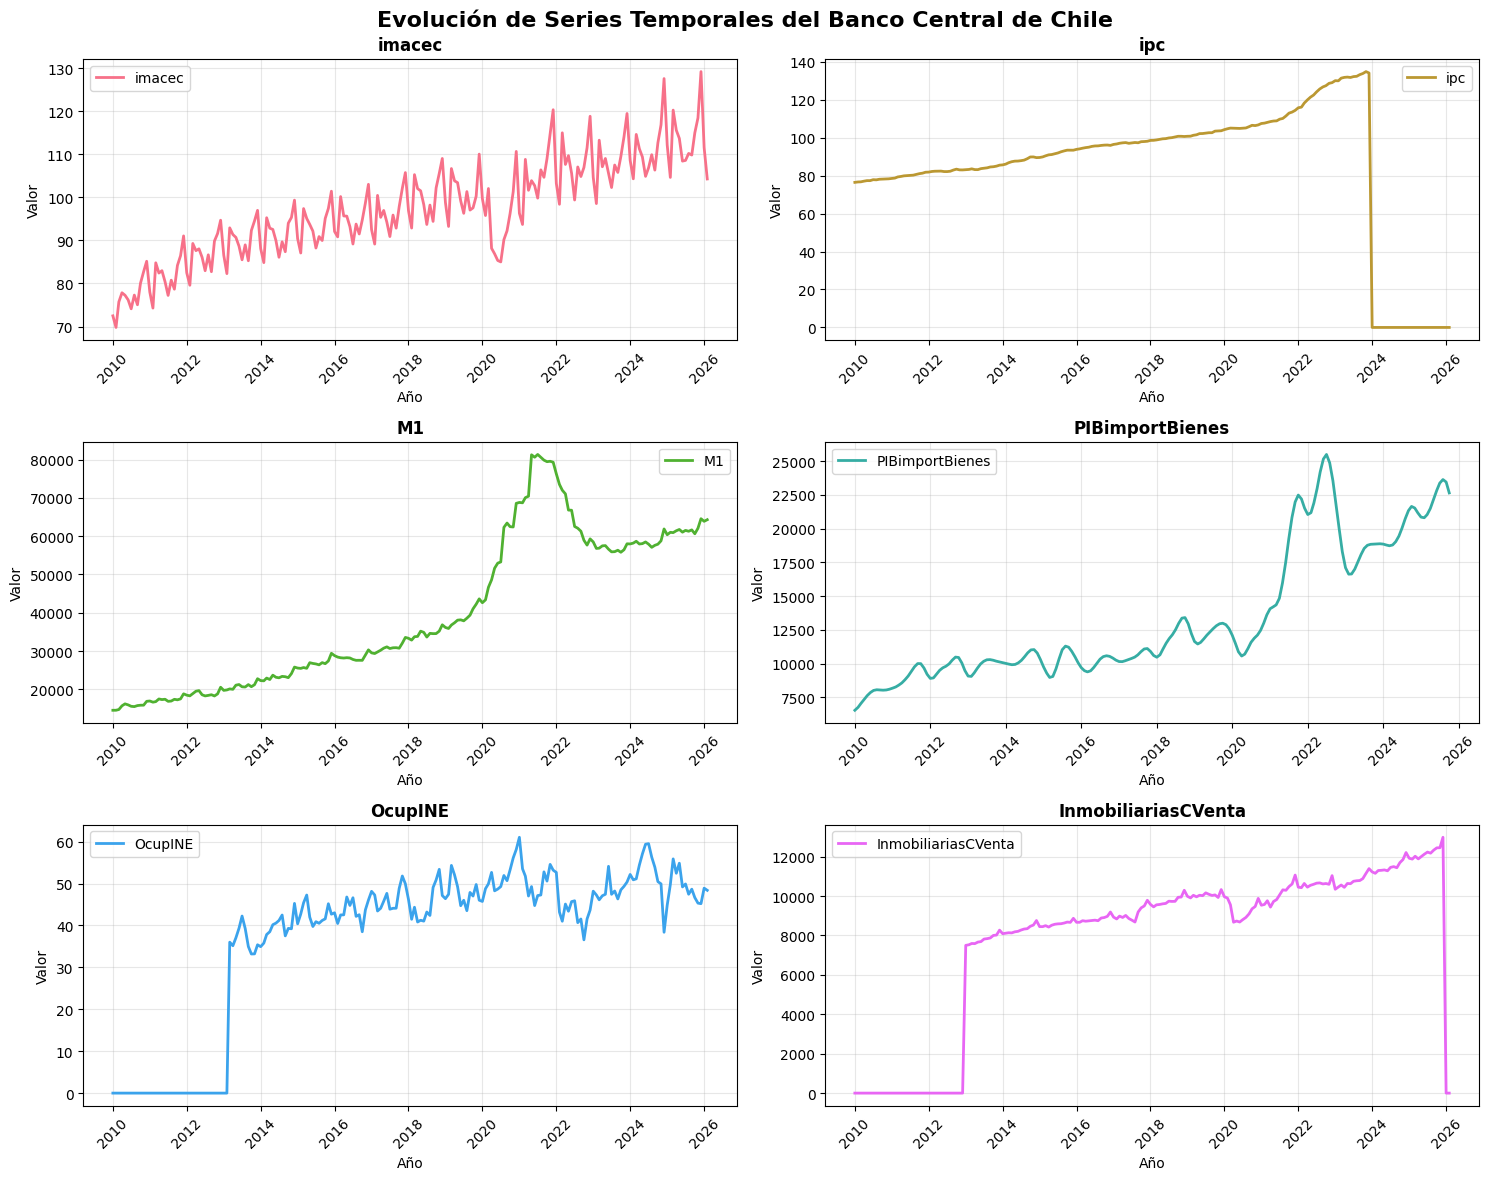

In [ ]:
# Crear figura con subplots para cada serie
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
fig.suptitle('Evolución de Series Temporales del Banco Central de Chile', fontsize=16, fontweight='bold')

# Aplanar los ejes para facilitar la iteración
axes = axes.flatten()

# Colores para cada serie
colors = sns.color_palette("husl", len(series_bc.columns))

# Plotear cada serie en un subplot
for idx, column in enumerate(series_bc.columns):
    ax = axes[idx]

    # Convertir el índice Period a timestamp para el plot
    series_bc_plot = series_bc.copy()
    series_bc_plot.index = series_bc_plot.index.to_timestamp()

    # Plotear la serie
    ax.plot(series_bc_plot.index, series_bc_plot[column],
            color=colors[idx], linewidth=2, label=column)

    # Configurar el subplot
    ax.set_title(column, fontsize=12, fontweight='bold')
    ax.set_xlabel('Año', fontsize=10)
    ax.set_ylabel('Valor', fontsize=10)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best')

# Ajustar el layout
plt.tight_layout()
plt.show()

In [ ]:
import meteostat as ms
import pandas as pd
from datetime import date

# Coordenadas de Santiago de Chile
POINT = ms.Point(-33.45, -70.67, 520)

# Rango de fechas
start = date(2010, 1, 1)
end   = date(2026, 12, 31)

# Obtener estaciones cercanas
stations = ms.stations.nearby(POINT, limit=4)

# Obtener datos diarios con interpolación
ts = ms.daily(stations, start, end)
data = ms.interpolate(ts, POINT).fetch()

# Agrupar por mes
data.index = pd.to_datetime(data.index).to_period('M')
clima_mes = data.groupby(data.index)[['tmin', 'tmax']].mean().round(1)
clima_mes.index = clima_mes.index.to_timestamp()  # necesario para matplotlib

clima_mes.head()

,tmin,tmax
time,,
2010-01-01,13.4,31.6
2010-02-01,11.9,29.9
2010-03-01,10.7,29.7
2010-04-01,6.0,24.7
2010-05-01,5.2,20.8


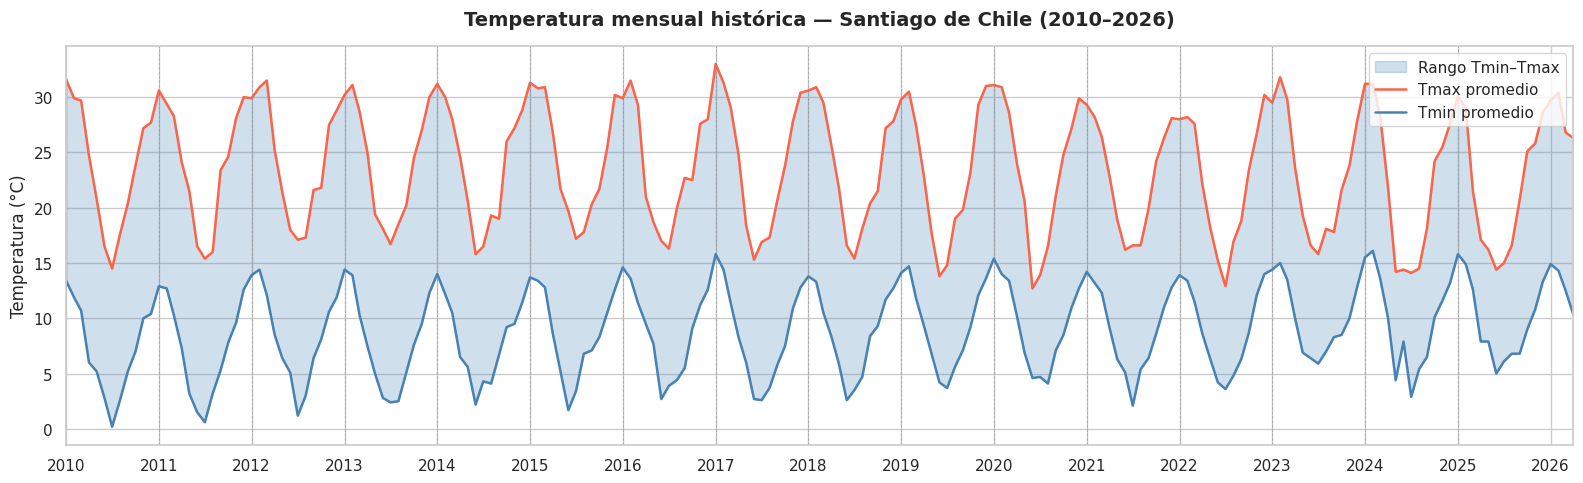

In [ ]:

# ── Gráfico ────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")

fig, ax = plt.subplots(figsize=(16, 5))

# Rango sombreado
ax.fill_between(
    clima_mes.index,
    clima_mes['tmin'],
    clima_mes['tmax'],
    alpha=0.25,
    color='steelblue',
    label='Rango Tmin–Tmax'
)

# Líneas
ax.plot(clima_mes.index, clima_mes['tmax'], color='tomato',     linewidth=1.8, label='Tmax promedio')
ax.plot(clima_mes.index, clima_mes['tmin'], color='steelblue',  linewidth=1.8, label='Tmin promedio')

# Eje X: una marca por año + etiquetas de mes abreviadas
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.MonthLocator())

# Líneas verticales por año
for year in range(2010, 2026):
    ax.axvline(pd.Timestamp(f'{year}-01-01'), color='gray', linewidth=0.6, linestyle='--', alpha=0.5)

# Etiquetas y estilo
ax.set_title('Temperatura mensual histórica — Santiago de Chile (2010–2026)', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Temperatura (°C)')
ax.set_xlabel('')
ax.legend(loc='upper right', framealpha=0.8)
ax.set_xlim(clima_mes.index.min(), clima_mes.index.max())

plt.tight_layout()
plt.savefig('santiago_temp_historica.png', dpi=150, bbox_inches='tight')
plt.show()